# 진자의 각도에 따른 속력과 알짜힘

질량이 없는 늘어나지 않는 줄에 매달린 질점을 초기 각도에서 **정지 상태로 놓는** 이상적인 진자입니다. 마찰과 공기 저항은 무시합니다. 각도 $\theta$는 수직 아래 방향을 기준으로 측정합니다.

초기 각도 15°, 30°, 45°, 60°, 75°, 90°를 비교합니다. 색은 15°의 빨간색에서 90°의 파란색으로 이어지며 두 그래프에서 같은 각도는 같은 색입니다. `initial_angles_deg`로 초기 각도 목록을 변경할 수 있습니다(0~90도). `L`은 줄 길이, `m`은 질량, `g`는 중력가속도입니다.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

initial_angles_deg = np.arange(15, 91, 15)
L = 1.0           # Length (m)
m = 1.0           # Mass (kg)
g = 9.81          # Gravitational acceleration (m/s^2)

initial_angles_deg = np.asarray(initial_angles_deg, dtype=float)
if initial_angles_deg.ndim != 1 or initial_angles_deg.size == 0:
    raise ValueError('initial_angles_deg must be a nonempty list of angles.')
if not np.all(np.isfinite(initial_angles_deg) & (initial_angles_deg >= 0) & (initial_angles_deg <= 90)):
    raise ValueError('Initial angles must be between 0 and 90 degrees.')
if not all(np.isfinite(value) and value > 0 for value in (L, m, g)):
    raise ValueError('L, m, and g must be finite positive numbers.')


## 계산식

역학적 에너지 보존으로부터 속력을 구합니다. 작은 각도 근사는 사용하지 않습니다.

$$v(\theta)=\sqrt{2gL(\cos\theta-\cos\theta_0)}$$

알짜힘은 **중력과 장력의 벡터 합**입니다. 접선 방향 성분은 $F_t=-mg\sin\theta$, 중심 방향 성분은 $F_r=mv^2/L$이므로,

$$|\vec F_{\mathrm{net}}|=\sqrt{(mg\sin\theta)^2+\left(\frac{mv^2}{L}\right)^2}$$

구심력은 별도로 추가되는 힘이 아니라 알짜힘의 중심 방향 성분입니다. 초기 각도가 0보다 크면 최저점에서 속력이 최대이며, 접선 방향 힘은 0이지만 알짜힘은 0이 아닙니다. 양 끝점에서는 속력은 0이지만 접선 방향 힘이 작용합니다. 같은 각도를 왕복할 때 속도 방향은 달라져도 속력과 알짜힘의 크기는 같습니다.

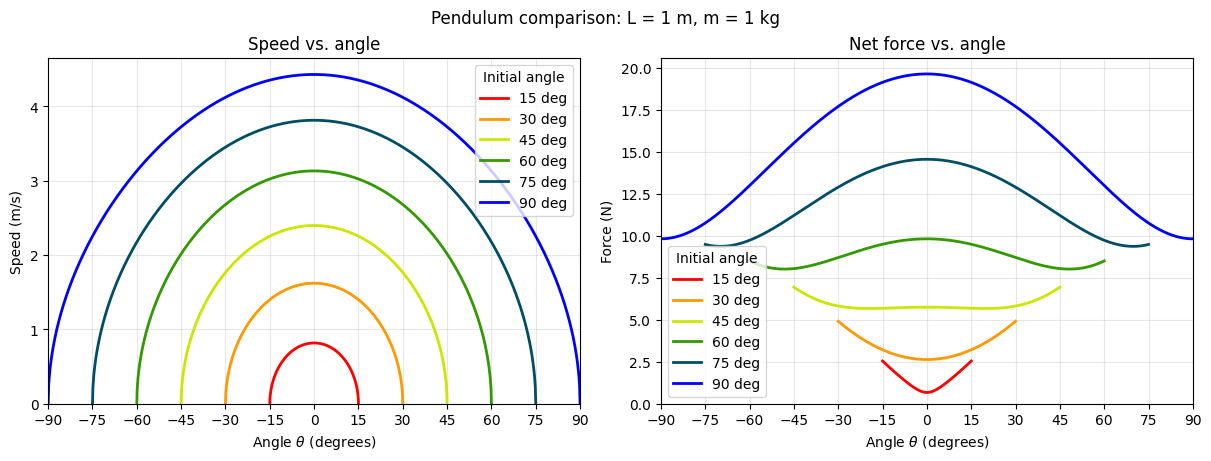

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for theta0_deg in initial_angles_deg:
    theta_deg = np.linspace(-theta0_deg, theta0_deg, 1001)
    theta = np.deg2rad(theta_deg)
    theta0 = np.deg2rad(theta0_deg)

    # Equivalent to cos(theta) - cos(theta0), stable for small angles.
    height_factor = 2 * np.sin((theta0 + theta) / 2) * np.sin((theta0 - theta) / 2)
    speed_squared = np.maximum(2 * g * L * height_factor, 0.0)
    speed = np.sqrt(speed_squared)
    force_tangential = -m * g * np.sin(theta)
    force_radial = m * speed_squared / L
    force_net = np.hypot(force_tangential, force_radial)

    fraction = np.clip((theta0_deg - 15) / (90 - 15), 0, 1)
    color = LinearSegmentedColormap.from_list('angle_colors', ['red', 'yellow', 'green', 'blue'])(float(fraction))
    label = f'{theta0_deg:g} deg'
    axes[0].plot(theta_deg, speed, color=color, linewidth=2, label=label)
    axes[1].plot(theta_deg, force_net, color=color, linewidth=2, label=label)
    if theta0_deg == 0:
        for ax in axes:
            ax.scatter([0], [0], color=color, zorder=3)

axes[0].set(title='Speed vs. angle', ylabel='Speed (m/s)')
axes[1].set(title='Net force vs. angle', ylabel='Force (N)')

for ax in axes:
    ax.set_xlabel(r'Angle $\theta$ (degrees)')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Initial angle')
    angle_limit = max(float(initial_angles_deg.max()), 1)
    ax.set_xlim(-angle_limit, angle_limit)
    ax.set_xticks(np.arange(-90, 91, 15))

fig.suptitle(f'Pendulum comparison: L = {L:g} m, m = {m:g} kg')
plt.show()
